In [1]:
import os
os.listdir()

['.config', 'sample_data']

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_ATS_v2.csv to Dataset_ATS_v2 (1).csv


In [8]:
import pandas as pd

df = pd.read_csv("Dataset_ATS_v2.csv")
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [9]:
df.shape

(7043, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [11]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
Contract,0
MonthlyCharges,0
Churn,0


In [12]:
df.duplicated().sum()

np.int64(302)

In [14]:
df = df.drop_duplicates()

In [15]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["Churn"].head()

,Churn
0,1
1,0
2,0
3,1
4,0


In [16]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
Contract,0
MonthlyCharges,0
Churn,0


In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,0,1,25,1,False,False,False,False,False,False,False
1,0,41,25,0,True,False,True,False,False,True,False
2,0,52,19,0,False,True,True,False,False,False,False
3,0,1,76,1,False,False,True,False,False,True,False
4,0,67,51,0,True,False,True,False,True,False,False


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5392, 10), (1349, 10))

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(5392, 10)

In [21]:
# Clutering Part

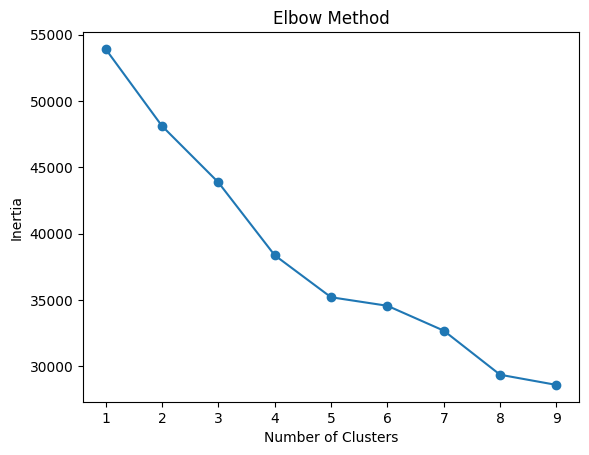

[2 3 3 3 3 2 0 1 0 2 2 2 2 1 2 2 2 3 0 3]
Cluster
2    1885
3    1734
1    1218
0     555
Name: count, dtype: int64


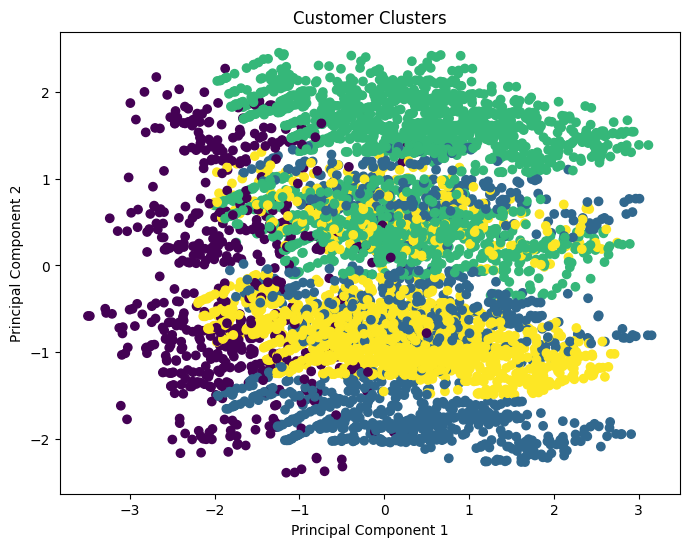

         SeniorCitizen     tenure  MonthlyCharges  gender_Male  \
Cluster                                                          
0             0.147748  31.580180       42.086486     0.535135   
1             0.156814  33.091954       68.996716     0.510673   
2             0.172944  33.337931       68.449337     0.517241   
3             0.179354  33.115340       68.758939     0.483276   

         Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
Cluster                                                        
0              0.286486               0.0           0.380180   
1              0.288998               1.0           0.507389   
2              0.317772               1.0           0.675332   
3              0.306228               1.0           0.107843   

         InternetService_Fiber optic  Contract_One year  Contract_Two year  
Cluster                                                                     
0                           0.437838           0.221622         

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Step 1: Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Step 2: Train KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

# Step 3: Check first few labels
print(clusters[:20])

# Step 4: Count customers in each cluster
cluster_df = pd.DataFrame(X_train_scaled)
cluster_df["Cluster"] = clusters
print(cluster_df["Cluster"].value_counts())

# Step 5: PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters")
plt.show()

# Step 6: Add clusters to original training data
X_train_copy = X_train.copy()
X_train_copy["Cluster"] = clusters

# Step 7: Interpret clusters
print(X_train_copy.groupby("Cluster").mean(numeric_only=True))

In [ ]:
# The KMeans algorithm segmented customers into four clusters. Cluster 2 has the largest group with **1,885 customers**, followed by Cluster 3 with **1,734**, Cluster 1 with **1,218**, and Cluster 0 with **555 customers**. Cluster 2 shows high **fiber optic usage (0.89)**, while Cluster 1 has **100% two-year contracts**, indicating more stable, long-term customers.


Confusion Matrix:
[[885 106]
 [197 161]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       991
           1       0.60      0.45      0.52       358

    accuracy                           0.78      1349
   macro avg       0.71      0.67      0.68      1349
weighted avg       0.76      0.78      0.76      1349


ROC-AUC Score:
0.8103673283010785


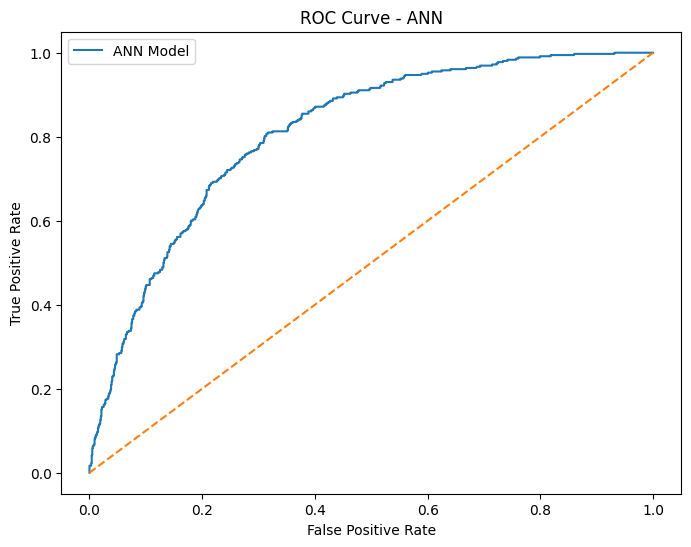

In [23]:
# Predictive Modeling (ANN – Artificial Neural Network)

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 1: Build the ANN model
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    early_stopping=True
)

# Step 2: Train the model
ann.fit(X_train_scaled, y_train)

# Step 3: Predict on test data
y_pred = ann.predict(X_test_scaled)
y_proba = ann.predict_proba(X_test_scaled)[:, 1]

# Step 4: Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_proba))

# Step 5: Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ANN Model')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")
plt.legend()
plt.show()

In [24]:
# Final Part



In the final stage of the project, we summarized the key findings from each part of the analysis. During the data preparation stage, the dataset contained **7,043 customer records**, and after checking the data we confirmed that there were **no missing values**, and the data was successfully split into **80% training and 20% testing sets**, resulting in about **5,392 training samples** used for modeling.

In the clustering stage, the KMeans algorithm divided customers into **four clusters**. The largest cluster contained **1,885 customers**, followed by **1,734 customers**, which helped us understand different customer segments and their service patterns.

In the predictive modeling stage, an **Artificial Neural Network** was trained to predict customer churn. The model achieved an accuracy of around **77% with an ROC-AUC of about 0.79**, indicating a reasonably strong prediction performance.

These results help the company identify high-risk customers and design better retention strategies to reduce churn.
